# Task 2 — Biomarker Embedding
## Step 1. Task 1 → Task 2 handoff
## Step 2. Dataset audit and harmonization

We begin Task 2 by freezing the exact glycans that should be interpreted, then auditing all external glycan resources before any embedding model is built. This order is deliberate: the quality and coverage of the metadata determine which learning objectives are realistic, and avoid building an embedding space on silently mismatched glycan representations.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()

for candidate in [PROJECT_ROOT, *PROJECT_ROOT.parents]:
    if (candidate / "pyproject.toml").exists():
        PROJECT_ROOT = candidate
        break

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.task2_embedding import (
    load_task2_inputs,
    load_task1_targets,
    build_task1_task2_handoff,
    audit_task2_sources,
    plot_task2_label_coverage,
    plot_task2_overlap_summary,
    plot_task2_source_sizes,
)

In [2]:
task2 = load_task2_inputs()

glycan_list = task2["glycan_list"]
df_glycan = task2["df_glycan"]
glycan_binding = task2["glycan_binding"]
n_glycans_df = task2["n_glycans_df"]

print("glycan_list:", glycan_list.shape)
print("df_glycan:", df_glycan.shape)
print("glycan_binding:", glycan_binding.shape)
print("n_glycans_df:", n_glycans_df.shape)
task2["paths"]

glycan_list: (5, 4)
df_glycan: (50461, 23)
glycan_binding: (2122, 2880)
n_glycans_df: (15712, 22)


{'glycan_list': WindowsPath('C:/Users/zakar/OneDrive/Bureau/ml-internship/data/glycan_embedding/glycan_list.csv'),
 'df_glycan': WindowsPath('C:/Users/zakar/OneDrive/Bureau/ml-internship/data/glycan_embedding/df_glycan.pkl'),
 'glycan_binding': WindowsPath('C:/Users/zakar/OneDrive/Bureau/ml-internship/data/glycan_embedding/glycan_binding.pkl'),
 'n_glycans_df': WindowsPath('C:/Users/zakar/OneDrive/Bureau/ml-internship/data/glycan_embedding/N_glycans_df.pkl')}

We first verify that all Task 2 inputs are readable and inspect their raw dimensionality. At this stage we do not assume any schema consistency, because the subsequent handoff and audit logic must tolerate different column conventions across CSV and pickle sources.

In [3]:
task1_targets = load_task1_targets()
task1_targets

,feature,qc_mean_intensity,qc_std_intensity,qc_cv_pct,qc_log_sd,qc_detection_rate,Dunn_mean_intensity,Dunn_std_intensity,Dunn_cv_pct,Dunn_log_sd,...,retained_high_confidence,exclusion_reason,redundancy_cluster_id,redundancy_cluster_size,candidate_isomer_neighbor_count,candidate_isotope_or_adduct_neighbor_count,high_corr_near_duplicate_neighbor_count,high_corr_other_neighbor_count,redundancy_representative_flag,redundancy_role
0,FT-145,1085.001386,173.356550,15.977542,0.155645,0.909091,860.100181,165.600263,19.253602,0.194992,...,True,retained,RG-001,2,0,1,0,0,True,representative
1,FT-015,1948.204868,335.924066,17.242749,0.179359,0.909091,2066.396647,570.960239,27.630718,0.806941,...,True,retained,RG-002,1,0,0,0,0,True,singleton
2,FT-174,28.534949,6.840222,23.971384,0.248808,0.909091,42.781426,85.144228,199.021480,0.966589,...,True,retained,RG-003,3,1,0,0,0,True,representative
3,FT-188,84.058692,24.552221,29.208426,0.285823,1.000000,153.373854,282.512535,184.198628,0.591367,...,True,retained,RG-004,4,1,2,0,0,False,member
4,FT-028,555.703429,136.732905,24.605374,0.271682,0.909091,639.351551,184.401834,28.842009,0.817646,...,True,retained,RG-005,1,0,0,0,0,True,singleton
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
192,FT-081,1296.401567,311.099502,23.997156,0.292451,1.000000,1351.968759,310.095368,22.936578,0.314756,...,False,retained,RG-009,24,0,9,0,0,False,member
193,FT-198,1321.679919,334.874280,25.337018,0.293755,1.000000,1411.793105,230.319862,16.313995,0.163770,...,False,retained,RG-013,2,0,1,0,0,False,member
194,FT-111,928.899079,216.923912,23.352796,0.298120,1.000000,941.933705,168.084810,17.844654,0.187175,...,False,retained,RG-016,8,2,0,0,0,False,member
195,FT-084,1021.185708,282.719561,27.685421,0.352293,1.000000,976.764202,166.927289,17.089825,0.174358,...,False,retained,RG-009,24,1,13,0,0,False,member


In [4]:
task1_task2_handoff, handoff_info = build_task1_task2_handoff(
    glycan_list=glycan_list,
    task1_targets=task1_targets,
)

pd.Series(handoff_info)

merge_mode            task1_only_no_mapping
n_task1_rows                            197
n_glycan_list_rows                        5
n_handoff_rows                          197
n_mapped_rows                             0
mapping_rate                            0.0
dtype: object

In [5]:
print(task1_task2_handoff.shape)
task1_task2_handoff.head(20)

(197, 6)


,feature_id,biomarker_tier,redundancy_cluster,clinical_profile,glycan_sequence,composition
0,FT-145,missing_tier,RG-001,NaN,NaN,NaN
1,FT-015,missing_tier,RG-002,NaN,NaN,NaN
2,FT-174,missing_tier,RG-003,NaN,NaN,NaN
3,FT-188,missing_tier,RG-004,NaN,NaN,NaN
4,FT-028,missing_tier,RG-005,NaN,NaN,NaN
5,FT-156,missing_tier,RG-006,NaN,NaN,NaN
6,FT-217,missing_tier,RG-007,NaN,NaN,NaN
7,FT-146,missing_tier,RG-001,NaN,NaN,NaN
8,FT-172,missing_tier,RG-008,NaN,NaN,NaN
9,FT-089,missing_tier,RG-009,NaN,NaN,NaN


The Task 1 → Task 2 handoff freezes the list of glycans that will receive interpretation priority in Task 2. We preserve biomarker tier, redundancy cluster, and Task 1 clinical profile because Task 2 should deepen the interpretation of the strongest discoveries rather than treat all identified glycans as equally important. At this point, the critical quality check is the mapping rate between Task 1 outputs and the CIRIS-identified glycan list.

In [6]:
audit = audit_task2_sources(
    glycan_list=glycan_list,
    df_glycan=df_glycan,
    glycan_binding=glycan_binding,
    n_glycans_df=n_glycans_df,
    task1_handoff=task1_task2_handoff,
)

audit["source_shapes"]

,source,n_rows,n_cols
0,glycan_list,5,4
1,df_glycan,50461,23
2,glycan_binding,2122,2880
3,N_glycans_df,15712,22


In [7]:
display(audit["source_uniques"])
display(audit["label_coverage"])
display(audit["overlap_summary"])
display(audit["binding_summary"])
display(audit["discovered_match_summary"])

,source,n_unique_glycans
0,glycan_list,5
1,df_glycan,50461
2,glycan_binding,2878
3,N_glycans_df,962
4,reference_union,51423
5,master_union,51425


,source,fraction_with_composition,fraction_with_tissue_sample,fraction_with_tissue_species,fraction_with_disease
0,glycan_list,1.0,1.0,1.0,0.000000
1,df_glycan,1.0,1.0,1.0,1.000000
2,N_glycans_df,1.0,1.0,1.0,1.000000
3,master_union,1.0,1.0,1.0,0.999961


,comparison,n_overlap,fraction_of_query,fraction_of_df_glycan,fraction_of_N_glycans_df
0,query ∩ df_glycan,3,0.6,NaN,NaN
1,query ∩ N_glycans_df,0,0.0,NaN,NaN
2,query ∩ glycan_binding,2,0.4,NaN,NaN
3,df_glycan ∩ glycan_binding,1415,NaN,0.028041,NaN
4,N_glycans_df ∩ df_glycan,0,NaN,NaN,0.0


,metric,value
0,n_binding_rows_long,651815.000000
1,n_unique_binding_glycans,2878.000000
2,n_unique_binding_proteins,1383.000000
3,fraction_query_with_binding,0.400000
4,fraction_reference_with_binding,0.027517


,metric,value
0,n_task1_handoff_rows,197.0
1,n_task1_rows_with_mapped_sequence,0.0
2,fraction_task1_rows_with_mapped_sequence,0.0
3,n_task1_rows_present_in_df_glycan,0.0
4,n_task1_rows_with_binding_support,0.0


In [8]:
print("query_standardized:", audit["query_standardized"].shape)
print("reference_standardized:", audit["reference_standardized"].shape)
print("binding_standardized:", audit["binding_standardized"].shape)
print("master_table:", audit["master_table"].shape)

display(audit["query_standardized"].head())
display(audit["reference_standardized"].head())
display(audit["binding_standardized"].head())
display(audit["master_table"].head())

query_standardized: (5, 8)
reference_standardized: (51423, 8)
binding_standardized: (651815, 3)
master_table: (51425, 9)


,glycan_sequence,composition,tissue_sample,tissue_species,disease,source_name,is_n_glycan,original_sequence_column
0,Fuc(a1-?)GlcNAc(b1-2)Man(a1-6)[GlcNAc(b1-2)Man...,"{'dHex': 2, 'HexNAc': 4, 'Hex': 3}",['blood'],['Homo_sapiens'],NaN,glycan_list,0,glycan
1,Neu5Ac(a2-?)Gal(b1-4)GlcNAc(b1-2)Man(a1-6)[Glc...,"{'Neu5Ac': 1, 'Hex': 4, 'HexNAc': 4, 'dHex': 1}",['blood'],['Homo_sapiens'],NaN,glycan_list,0,glycan
2,Neu5Ac(a2-6)Gal(b1-4)GlcNAc(b1-2)Man(a1-6)[Gal...,"{'Neu5Ac': 1, 'Hex': 5, 'HexNAc': 4}",['blood'],['Homo_sapiens'],NaN,glycan_list,0,glycan
3,Neu5Ac(a2-6)Gal(b1-4)GlcNAc(b1-2)Man(a1-6)[Glc...,"{'Neu5Ac': 1, 'Hex': 4, 'HexNAc': 4}",['blood'],['Homo_sapiens'],NaN,glycan_list,0,glycan
4,Fuc(a1-2)[GalNAc(a1-3)]Gal(b1-4)GlcNAc(b1-2)Ma...,"{'dHex': 1, 'HexNAc': 5, 'Hex': 5}",['blood'],['Homo_sapiens'],NaN,glycan_list,0,glycan


,glycan_sequence,composition,tissue_sample,tissue_species,disease,is_n_glycan,sources,in_reference
0,"1,5-Anhydro-ManNAc-ol(2-4)GlcNAc1N",{'HexNAc': 2},[],[],[],0,df_glycan,1
1,"2,3-Anhydro-Man(a1-4)Glc(a1-4)Glc",{'Hex': 3},[],[],[],0,df_glycan,1
2,"2,3-Anhydro-Man(a1-4)Glc(a1-4)Glc-ol",{'Hex': 3},[],[],[],0,df_glycan,1
3,"2,3-Anhydro-Man(a1-?)Glc(?1-?)Glc",{'Hex': 3},[],[],[],0,df_glycan,1
4,"2,3-Anhydro-Man(a1-?)Glc(?1-?)Glc-ol",{'Hex': 3},[],[],[],0,df_glycan,1


,protein,glycan_sequence,binding_value
0,Dectin-1,3-Anhydro-Gal(a1-3)Gal(b1-4)3-Anhydro-Gal(a1-3...,0.010219
1,CLECSF8,3-Anhydro-Gal(a1-3)Gal(b1-4)3-Anhydro-Gal(a1-3...,-0.423532
2,CMA,3-Anhydro-Gal(a1-3)Gal(b1-4)3-Anhydro-Gal(a1-3...,-0.309859
3,Malectin,3-Anhydro-Gal(a1-3)Gal(b1-4)3-Anhydro-Gal(a1-3...,-0.075725
4,Dectin-1,3-Anhydro-Gal(a1-3)Gal4S(b1-4)3-Anhydro-Gal(a1...,-0.079522


,glycan_sequence,composition,tissue_sample,tissue_species,disease,is_n_glycan,in_reference,in_query,sources
0,Fuc(a1-2)[GalNAc(a1-3)]Gal(b1-4)GlcNAc(b1-2)Ma...,"{'Hex': 5, 'HexNAc': 5, 'dHex': 1}",[plasma],[Homo_sapiens],[],0,1,1,df_glycan
1,Neu5Ac(a2-6)Gal(b1-4)GlcNAc(b1-2)Man(a1-6)[Gal...,"{'Hex': 5, 'HexNAc': 4, 'Neu5Ac': 1}","[AML_193_cell_line, EOL_1_cell_line, HEL92_1_7...","[Homo_sapiens, Homo_sapiens, Homo_sapiens, Hom...",[],0,1,1,df_glycan
2,Neu5Ac(a2-6)Gal(b1-4)GlcNAc(b1-2)Man(a1-6)[Glc...,"{'Hex': 4, 'HexNAc': 4, 'Neu5Ac': 1}","[blood, mucosa_of_stomach, seminal_fluid]","[Homo_sapiens, Homo_sapiens, Homo_sapiens]",[],0,1,1,df_glycan
3,Fuc(a1-?)GlcNAc(b1-2)Man(a1-6)[GlcNAc(b1-2)Man...,"{'dHex': 2, 'HexNAc': 4, 'Hex': 3}",['blood'],['Homo_sapiens'],NaN,0,0,1,NaN
4,Neu5Ac(a2-?)Gal(b1-4)GlcNAc(b1-2)Man(a1-6)[Glc...,"{'Neu5Ac': 1, 'Hex': 4, 'HexNAc': 4, 'dHex': 1}",['blood'],['Homo_sapiens'],NaN,0,0,1,NaN


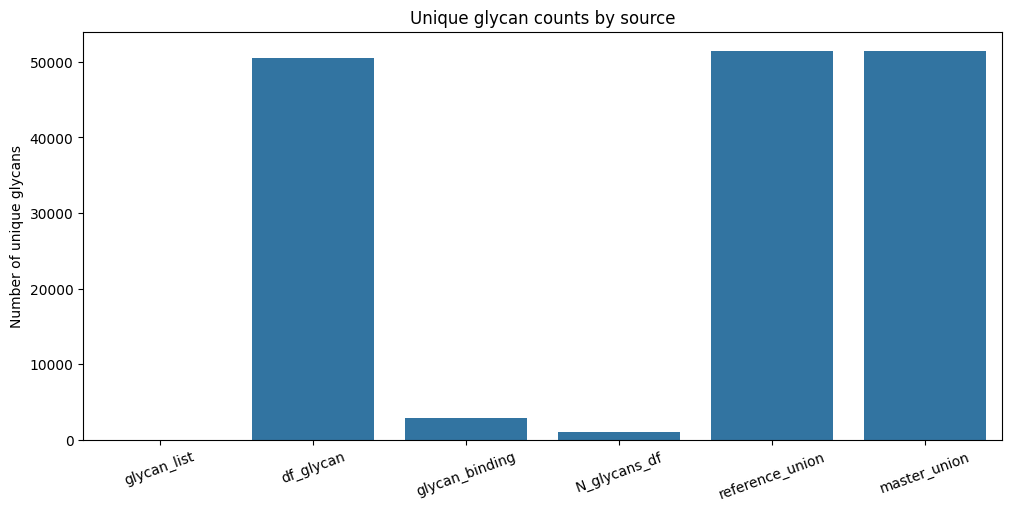

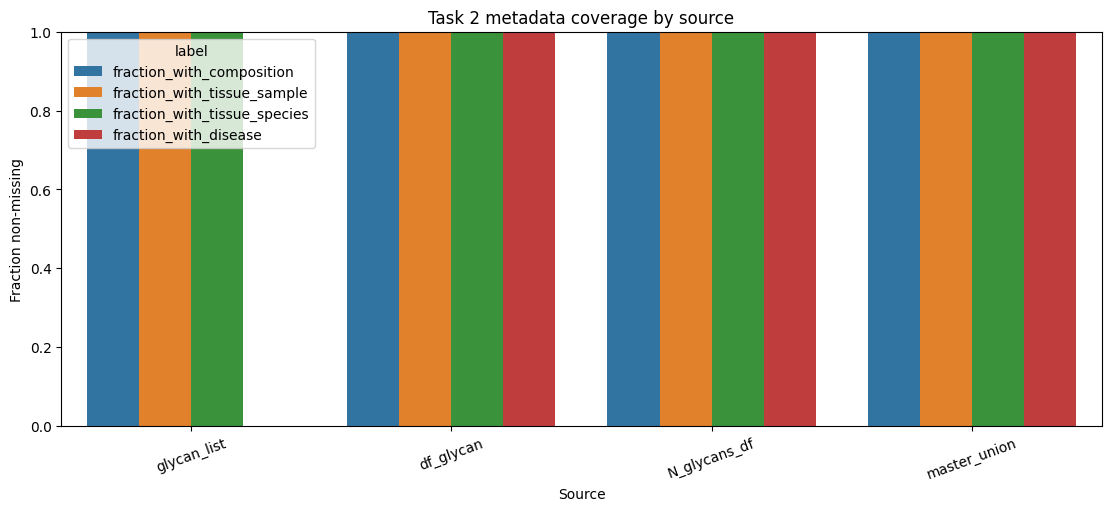

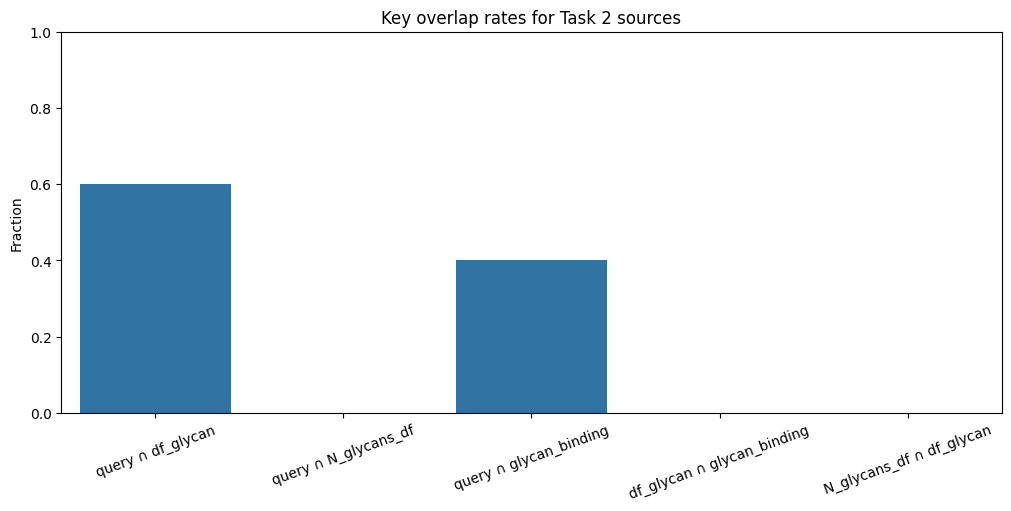

In [9]:
fig = plot_task2_source_sizes(audit["source_uniques"])
plt.show()

fig = plot_task2_label_coverage(audit["label_coverage"])
plt.show()

fig = plot_task2_overlap_summary(audit["overlap_summary"])
plt.show()

The audit quantifies three things that directly constrain the later embedding design:  
1. how many discovered glycans can be matched to the external glycan universe,  
2. how rich the metadata supervision is for species, tissue, disease, and binding, and  
3. whether the provided N-glycan control set substantially overlaps the reference glycan space.

These results determine whether later modeling should emphasize structure-first representations, metadata-aware enrichment, or binding-aware enrichment. In particular, sparse disease coverage would argue against making disease supervision the main training target.

## Step 3 — Canonical notation and canonical glycan master table

The Step 2 audit showed that exact overlap with the external glycan resources is only partial and that some metadata coverage estimates were inflated by empty list-like entries being counted as non-missing. We therefore standardize glycan notation more carefully and define a canonical master table before constructing any representation space.

We use two sequence keys:
- an exact cleaned sequence as the primary identifier,
- a relaxed topology key as a secondary matching key for notation-tolerant comparisons.

This is a conservative way to reduce silent mismatch without over-claiming exact structural equivalence.

In [10]:
from src.task2_embedding import (
    build_step3_canonical_master,
    summarize_step3_master,
    plot_step3_query_match_status,
    build_step4_baseline_spaces,
    evaluate_step4_baselines,
    plot_step4_baseline_comparison,
    build_step4_modeling_subset,
    summarize_step4_modeling_subset,
)


In [11]:
canonical_master = build_step3_canonical_master(
    master_table=audit["master_table"],
    binding_standardized=audit["binding_standardized"],
)

print(canonical_master.shape)
canonical_master.head()

(51425, 54)


,glycan_sequence,composition,tissue_sample,tissue_species,disease,is_n_glycan,in_reference,in_query,sources,canonical_sequence,...,n_binding_rows,n_binding_proteins,mean_binding_value,max_binding_value,n_binding_rows_topology,n_binding_proteins_topology,has_binding_exact,has_binding_topology,discovered_flag,reference_flag
0,Fuc(a1-2)[GalNAc(a1-3)]Gal(b1-4)GlcNAc(b1-2)Ma...,"{'Hex': 5, 'HexNAc': 5, 'dHex': 1}",[plasma],[Homo_sapiens],[],0,1,1,df_glycan,Fuc(a1-2)[GalNAc(a1-3)]Gal(b1-4)GlcNAc(b1-2)Ma...,...,0.0,0.0,0.000000,0.000000,0.0,0.0,0,0,1,1
1,Neu5Ac(a2-6)Gal(b1-4)GlcNAc(b1-2)Man(a1-6)[Gal...,"{'Hex': 5, 'HexNAc': 4, 'Neu5Ac': 1}","[AML_193_cell_line, EOL_1_cell_line, HEL92_1_7...","[Homo_sapiens, Homo_sapiens, Homo_sapiens, Hom...",[],0,1,1,df_glycan,Neu5Ac(a2-6)Gal(b1-4)GlcNAc(b1-2)Man(a1-6)[Gal...,...,1362.0,1162.0,-0.019202,15.881176,2835.0,1173.0,1,1,1,1
2,Neu5Ac(a2-6)Gal(b1-4)GlcNAc(b1-2)Man(a1-6)[Glc...,"{'Hex': 4, 'HexNAc': 4, 'Neu5Ac': 1}","[blood, mucosa_of_stomach, seminal_fluid]","[Homo_sapiens, Homo_sapiens, Homo_sapiens]",[],0,1,1,df_glycan,Neu5Ac(a2-6)Gal(b1-4)GlcNAc(b1-2)Man(a1-6)[Glc...,...,1300.0,1115.0,-0.004365,7.004782,2573.0,1115.0,1,1,1,1
3,Fuc(a1-?)GlcNAc(b1-2)Man(a1-6)[GlcNAc(b1-2)Man...,"{'dHex': 2, 'HexNAc': 4, 'Hex': 3}",['blood'],['Homo_sapiens'],NaN,0,0,1,NaN,Fuc(a1-?)GlcNAc(b1-2)Man(a1-6)[GlcNAc(b1-2)Man...,...,0.0,0.0,0.000000,0.000000,0.0,0.0,0,0,1,0
4,Neu5Ac(a2-?)Gal(b1-4)GlcNAc(b1-2)Man(a1-6)[Glc...,"{'Neu5Ac': 1, 'Hex': 4, 'HexNAc': 4, 'dHex': 1}",['blood'],['Homo_sapiens'],NaN,0,0,1,NaN,Neu5Ac(a2-?)Gal(b1-4)GlcNAc(b1-2)Man(a1-6)[Glc...,...,0.0,0.0,0.000000,0.000000,9.0,9.0,0,1,1,0


In [12]:
step3_summary = summarize_step3_master(canonical_master)
step3_summary

,metric,value
0,n_unique_canonical_glycans,51425.000000
1,n_discovered_glycans,5.000000
2,n_exact_binding_supported,1415.000000
3,fraction_with_tissue_sample_semantic,0.139874
4,fraction_with_tissue_species_semantic,0.137618
5,fraction_with_disease_semantic,0.014390
6,fraction_likely_n_glycan,0.095401


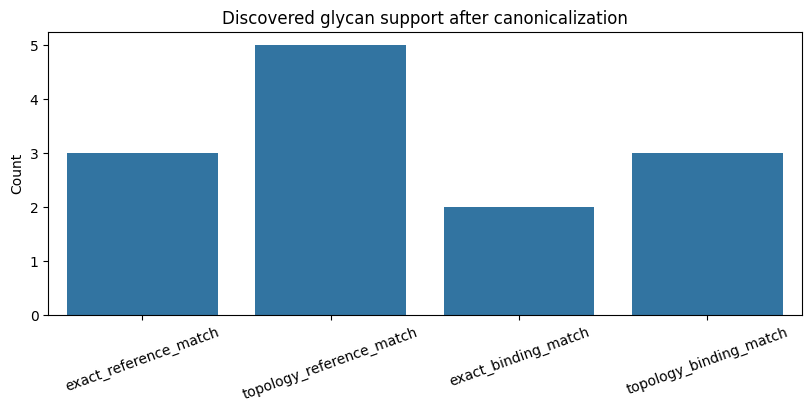

In [13]:
fig = plot_step3_query_match_status(canonical_master)
plt.show()

After semantic normalization and canonicalization, the master table becomes the single reference object for downstream modeling. This table separates exact sequence matching from topology-level matching, which is important because part of the low overlap observed in Step 2 likely came from notation differences rather than true biological absence.

At this point, we have enough support to continue with structure-first baselines, but still not enough evidence to make metadata-heavy supervision the main training objective.

## Step 4 — Interpretable baseline feature spaces

Before using any graph-aware or more complex embedding model, we build interpretable baseline spaces. This follows the assignment’s recommendation to benchmark simpler approaches first.

We compare three views of the same glycan universe:
1. composition-only,
2. sequence-token,
3. motif-based annotation.

These baselines help us test whether meaningful organization is already captured by simple chemistry and motif structure before adding more complex modeling.

In [14]:
from src.task2_embedding import (
    sanitize_motif_input_sequences,
    summarize_motif_input_qc,
    preview_rejected_motif_sequences,
    build_composition_baseline,
    build_sequence_token_baseline,
)

In [15]:
step4_subset = build_step4_modeling_subset(
    canonical_master=canonical_master,
    n_reference_sample=3000,
    random_state=42,
)

summarize_step4_modeling_subset(step4_subset)


,metric,value
0,n_total,8870
1,n_discovered,5
2,n_is_n_glycan,962
3,n_likely_n_glycan,4906
4,n_exact_binding_supported,285


In [16]:
composition_block = build_composition_baseline(step4_subset)
sequence_token_block = build_sequence_token_baseline(step4_subset)
baseline_spaces = {
    "composition": composition_block,
    "sequence_token": sequence_token_block,
}

for name, block in baseline_spaces.items():
    print(name, block.shape)

baseline_spaces["composition"].head()


composition (8870, 22)
sequence_token (8870, 1841)


,comp_Hex,comp_HexNAc,comp_dHex,comp_Neu5Ac,comp_Neu5Gc,comp_Kdn,comp_Fuc,comp_Xyl,comp_Gal,comp_Glc,...,comp_fucose_total,comp_sialic_total,comp_fucose_ratio,comp_sialic_ratio,comp_hexnac_to_hex_ratio,branch_count,unknown_token_count,monosaccharide_token_count,fucose_token_count,sialic_token_count
canonical_sequence,,,,,,,,,,,,,,,,,,,,,
Fuc(a1-2)[GalNAc(a1-3)]Gal(b1-4)GlcNAc(b1-2)Man(a1-6)[Gal(b1-4)GlcNAc(b1-2)Man(a1-3)]Man(b1-4)GlcNAc(b1-4)GlcNAc,5.0,5.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.090909,0.000000,1.000000,2.0,0.0,11.0,1.0,0.0
Neu5Ac(a2-6)Gal(b1-4)GlcNAc(b1-2)Man(a1-6)[Gal(b1-4)GlcNAc(b1-2)Man(a1-3)]Man(b1-4)GlcNAc(b1-4)GlcNAc,5.0,4.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.000000,0.100000,0.800000,1.0,0.0,10.0,0.0,1.0
Neu5Ac(a2-6)Gal(b1-4)GlcNAc(b1-2)Man(a1-6)[GlcNAc(b1-2)Man(a1-3)]Man(b1-4)GlcNAc(b1-4)GlcNAc,4.0,4.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.000000,0.111111,1.000000,1.0,0.0,9.0,0.0,1.0
Fuc(a1-?)GlcNAc(b1-2)Man(a1-6)[GlcNAc(b1-2)Man(a1-3)]Man(b1-4)GlcNAc(b1-4)[Fuc(a1-6)]GlcNAc,3.0,4.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2.0,0.0,0.222222,0.000000,1.333333,2.0,1.0,9.0,2.0,0.0
Neu5Ac(a2-?)Gal(b1-4)GlcNAc(b1-2)Man(a1-6)[GlcNAc(b1-2)Man(a1-3)]Man(b1-4)GlcNAc(b1-4)[Fuc(a1-6)]GlcNAc,4.0,4.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,0.100000,0.100000,1.000000,2.0,1.0,10.0,1.0,1.0


In [17]:
baseline_comparison = evaluate_step4_baselines(
    baseline_spaces=baseline_spaces,
    canonical_master=step4_subset,
)

baseline_comparison

,baseline_name,n_rows,n_features,density,mean_active_features_per_glycan,interpretability,n_glycan_prevalence,n_glycan_silhouette,n_glycan_knn_purity_at5,purity_minus_prevalence
0,sequence_token,8870,1841,0.020165,37.124577,medium-high,0.108455,0.416827,0.998753,0.890297
1,composition,8870,22,0.384483,8.458625,high,0.108455,0.364367,0.996674,0.888218


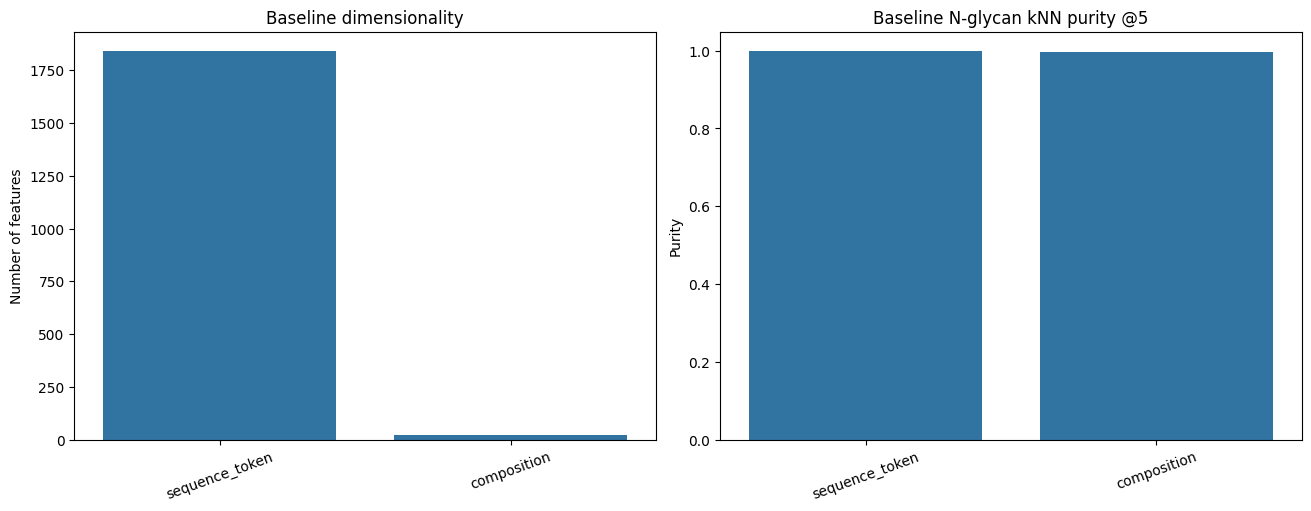

In [18]:
fig = plot_step4_baseline_comparison(baseline_comparison)
plt.show()

The baseline comparison is used as a decision gate before any more complex embedding model. In particular, we look for whether N-glycan controls show better local coherence than random expectation and whether one interpretable representation is clearly stronger than the others.

If a simple composition or motif space already captures strong structural organization, then a more complex model must justify itself by measurable improvement rather than by complexity alone.

## Step 5 — Validation tasks

The Step 4 baselines already show strong N-glycan coherence, so the next question is not whether the space looks organized, but whether it preserves biologically meaningful relationships beyond that primary control. We therefore define explicit validation tasks for N-glycan coherence, metadata neighborhood preservation, binding relevance, and discovered-glycan retrieval.

In [19]:
from src.task2_embedding import (
    summarize_step5_validation_feasibility,
    build_step6_embedding_suite,
    evaluate_embedding_suite,
    build_linear_embedding_layout,
    plot_embedding_layout,
    plot_embedding_suite_comparison,
    retrieve_discovered_glycan_neighbors,
)

In [20]:
step5_feasibility = summarize_step5_validation_feasibility(
    canonical_master=step4_subset,
    binding_standardized=audit["binding_standardized"],
)
step5_feasibility

,task,n_eligible,fraction_eligible,status
0,N-glycan coherence,962,0.108455,primary
1,tissue-species neighborhood preservation,1917,0.216122,secondary
2,tissue-sample neighborhood preservation,1938,0.218489,secondary
3,disease neighborhood preservation,269,0.030327,weak_secondary
4,discovered-glycan retrieval,5,0.000564,primary
5,binding relevance,285,0.032131,secondary


The feasibility table confirms the current modeling priorities. N-glycan coherence and discovered-glycan retrieval are the strongest primary tasks, while tissue/sample metadata and binding provide secondary evaluation axes. Disease metadata is too sparse to act as a main supervision target and is therefore retained only as a weak contextual signal.

## Step 6–8 — First-generation linear embeddings, late fusion, and ablation

Because the composition and sequence-token baselines already perform strongly, we first test lightweight linear fused embeddings before considering any graph-aware or deep model. This lets us measure whether metadata and binding actually add information beyond structural features alone.

In [21]:
embedding_suite = build_step6_embedding_suite(
    canonical_master=step4_subset,
    binding_standardized=audit["binding_standardized"],
    metadata_min_count=25,
    binding_min_protein_count=20,
    binding_top_n_proteins=256,
    comp_n_components=12,
    seq_n_components=32,
    meta_n_components=16,
    bind_n_components=16,
)

for block_name, block in embedding_suite["raw_blocks"].items():
    print("raw", block_name, block.shape)

for block_name, block in embedding_suite["reduced_blocks"].items():
    print("reduced", block_name, block.shape)

for emb_name, emb in embedding_suite["candidate_embeddings"].items():
    print("embedding", emb_name, emb.shape)

raw composition (8870, 22)
raw sequence_token (8870, 1841)
raw metadata (8870, 156)
raw binding (8870, 256)
reduced composition (8870, 12)
reduced sequence_token (8870, 32)
reduced metadata (8870, 16)
reduced binding (8870, 16)
embedding composition_only (8870, 12)
embedding sequence_token_only (8870, 32)
embedding structure (8870, 44)
embedding structure_metadata (8870, 60)
embedding structure_metadata_binding (8870, 76)


In [22]:
embedding_eval = evaluate_embedding_suite(
    embedding_suite=embedding_suite,
    canonical_master=step4_subset,
    k=5,
)
embedding_eval

,embedding_name,n_dimensions,n_glycan_silhouette,n_glycan_knn_purity_at5,species_neighbor_purity_at5,species_labeled_anchors,sample_neighbor_purity_at5,sample_labeled_anchors,disease_neighbor_purity_at5,disease_labeled_anchors,binding_jaccard_at5,binding_labeled_anchors
0,sequence_token_only,32,0.359461,0.998545,0.309859,1917.0,0.215996,1938.0,0.070632,269.0,0.137768,276.0
1,structure,44,0.317700,0.996050,0.407825,1917.0,0.302786,1938.0,0.133829,269.0,0.121278,276.0
2,composition_only,12,0.132056,0.982536,0.354304,1917.0,0.253148,1938.0,0.110037,269.0,0.175106,276.0
3,structure_metadata_binding,76,0.132260,0.980042,0.777778,1917.0,0.676367,1938.0,0.228253,269.0,0.281007,276.0
4,structure_metadata,60,0.132553,0.977339,0.781534,1917.0,0.678122,1938.0,0.230483,269.0,0.120069,276.0


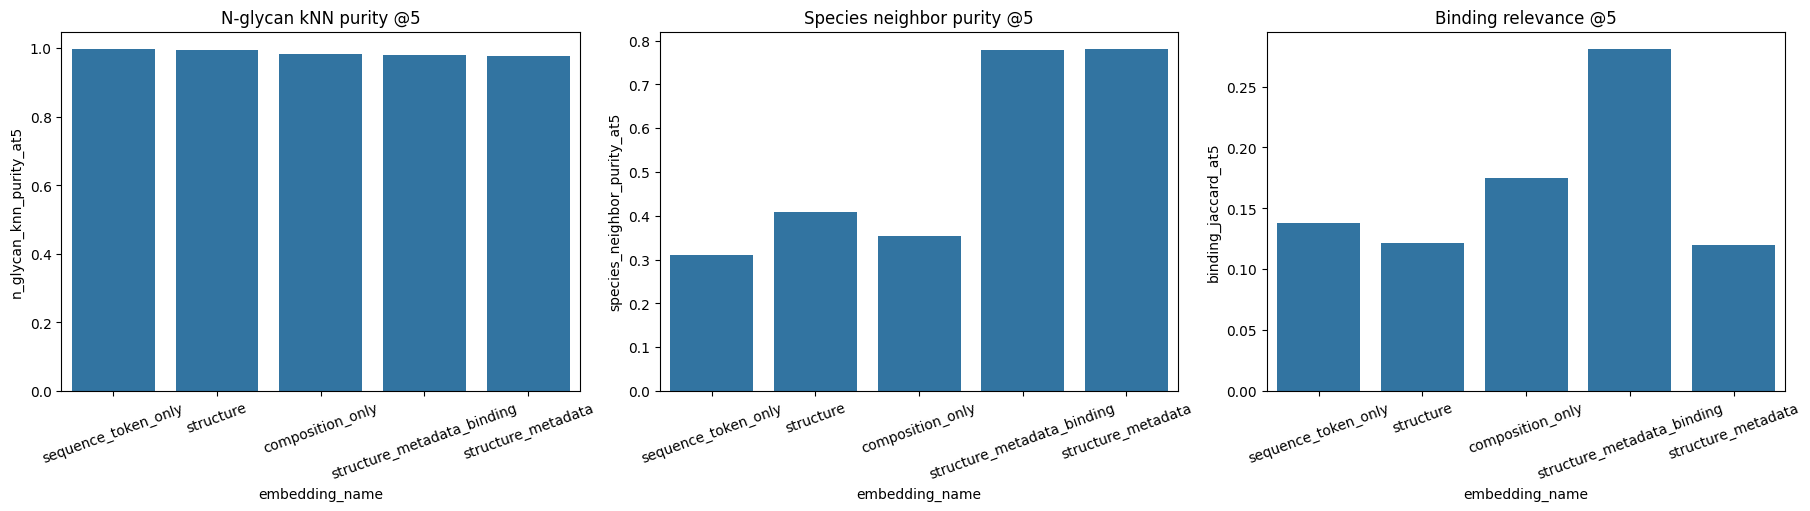

In [23]:
fig = plot_embedding_suite_comparison(embedding_eval)
plt.show()

The ablation table is the main decision object for the next stage. If structure-only embeddings already capture most of the useful signal, then richer multimodal fusion must justify itself by improving metadata neighborhood quality, binding relevance, or discovered-glycan retrieval rather than by adding complexity alone.

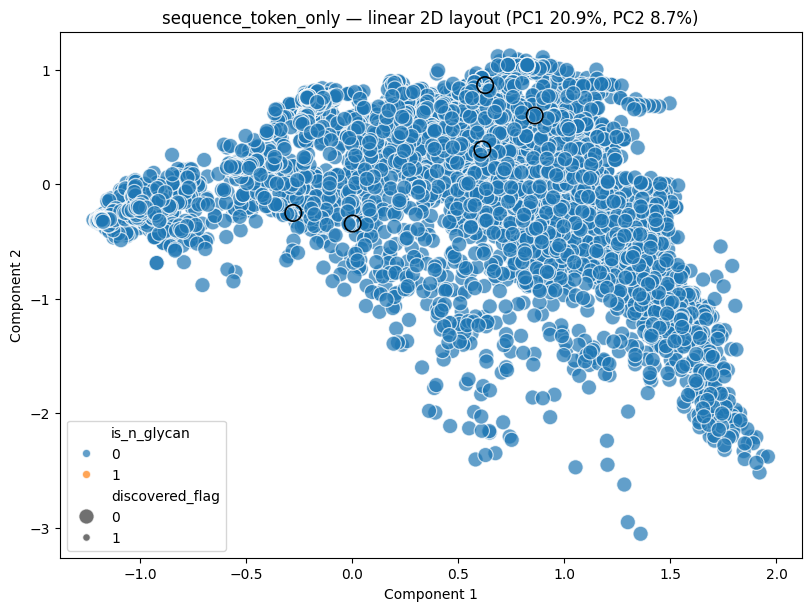

In [24]:
layout_seq = build_linear_embedding_layout(
    embedding_df=embedding_suite["candidate_embeddings"]["sequence_token_only"],
    canonical_master=step4_subset,
    embedding_name="sequence_token_only",
)

fig = plot_embedding_layout(layout_seq, color_by="is_n_glycan")
plt.show()

The 2D layouts are used only as diagnostic views. They help check whether the stronger embeddings preserve the expected N-glycan structure and whether discovered glycans fall in plausible local neighborhoods, but they are not treated as the primary quantitative evidence.

In [25]:
discovered_neighbors = retrieve_discovered_glycan_neighbors(
    embedding_df=embedding_suite["candidate_embeddings"]["structure_metadata_binding"],
    canonical_master=step4_subset,
    k=10,
)

discovered_neighbors.head(30)

,anchor_sequence,neighbor_rank,neighbor_sequence,neighbor_is_n_glycan,neighbor_has_binding_exact,neighbor_tissue_species,neighbor_disease,neighbor_reference_flag,neighbor_discovered_flag
0,Fuc(a1-2)[GalNAc(a1-3)]Gal(b1-4)GlcNAc(b1-2)Ma...,1,Fuc(a1-2)[GalNAc(a1-3)]Gal(b1-4)GlcNAc(b1-2)Ma...,0,0,Homo_sapiens,NaN,1,0
1,Fuc(a1-2)[GalNAc(a1-3)]Gal(b1-4)GlcNAc(b1-2)Ma...,2,Fuc(a1-2)[GalNAc(a1-3)]Gal(b1-4)GlcNAc(b1-2/6)...,0,0,Homo_sapiens,NaN,1,0
2,Fuc(a1-2)[GalNAc(a1-3)]Gal(b1-4)GlcNAc(b1-2)Ma...,3,Fuc(a1-2)[Gal(a1-3)]Gal(b1-4)GlcNAc(b1-2)Man(a...,0,0,Homo_sapiens,NaN,1,0
3,Fuc(a1-2)[GalNAc(a1-3)]Gal(b1-4)GlcNAc(b1-2)Ma...,4,Fuc(a1-2)[Gal(a1-3)]Gal(b1-4)GlcNAc(b1-2)Man(a...,0,0,Homo_sapiens,NaN,1,0
4,Fuc(a1-2)[GalNAc(a1-3)]Gal(b1-4)GlcNAc(b1-2)Ma...,5,Fuc(a1-2)Gal(b1-4)GlcNAc(b1-2)Man(a1-6)[Gal(b1...,0,1,Homo_sapiens,NaN,1,0
5,Fuc(a1-2)[GalNAc(a1-3)]Gal(b1-4)GlcNAc(b1-2)Ma...,6,Fuc(a1-2)Gal(b1-4)GlcNAc(b1-2/6)[Gal(b1-4)GlcN...,0,0,Homo_sapiens,NaN,1,0
6,Fuc(a1-2)[GalNAc(a1-3)]Gal(b1-4)GlcNAc(b1-2)Ma...,7,{GlcNAc(b1-4/6)}Neu5Ac(a2-3/6)Gal(b1-4)GlcNAc(...,0,0,Homo_sapiens,NaN,1,0
7,Fuc(a1-2)[GalNAc(a1-3)]Gal(b1-4)GlcNAc(b1-2)Ma...,8,Fuc(a1-2)[GalNAcOMe(a1-3)]Gal(b1-3)GlcNAc(b1-2...,0,0,NaN,NaN,1,0
8,Fuc(a1-2)[GalNAc(a1-3)]Gal(b1-4)GlcNAc(b1-2)Ma...,9,Fuc(a1-2)[GalNAcOMe(a1-3)]Gal(b1-3)GlcNAc(b1-2...,0,0,NaN,NaN,1,0
9,Fuc(a1-2)[GalNAc(a1-3)]Gal(b1-4)GlcNAc(b1-2)Ma...,10,Fuc(a1-2)[GalNAcOMe(a1-3)]GalOS(b1-3)GlcNAc(b1...,0,0,NaN,NaN,1,0


The discovered-glycan retrieval table is the first direct Task 2 interpretation object. For each discovered glycan, we inspect whether the nearest neighbors are structurally plausible, whether they connect to known N-glycan contexts, and whether metadata or binding information adds interpretable context beyond composition alone.

## Decision point  — choose the final interpretation embedding

The ablation results show a clear tradeoff. The sequence-token embedding preserves structural coherence best, while the structure + metadata + binding embedding provides the strongest contextual neighborhoods for species, sample, disease, and binding. Because Task 2 is primarily an interpretation task rather than a pure structural clustering task, we select the contextual embedding as the main downstream representation and keep the sequence-token embedding as a structural reference.

In [26]:
from src.task2_embedding import (
    build_final_interpretation_set,
    summarize_final_interpretation_set,
    filter_embedding_suite_to_universe,
    choose_final_embedding_name,
    summarize_discovered_glycan_neighborhoods,
    plot_discovered_neighbor_distances,
    plot_discovered_neighbor_support,
    build_neighbor_context_table,
)

In [27]:
final_interpretation_set = build_final_interpretation_set(
    canonical_master=step4_subset,
    require_reference_or_discovered=True,
    require_plausible_sequence=True,
)

summarize_final_interpretation_set(final_interpretation_set)

,metric,value
0,n_total,8285
1,n_discovered,5
2,n_reference,8283
3,n_n_glycans,379
4,n_likely_n_glycans,4906
5,n_binding_exact,285
6,n_species_labeled,1426
7,n_sample_labeled,1447
8,n_disease_labeled,132


In [28]:
filtered_embedding_suite = filter_embedding_suite_to_universe(
    embedding_suite=embedding_suite,
    interpretation_set=final_interpretation_set,
)

for emb_name, emb in filtered_embedding_suite["candidate_embeddings"].items():
    print(emb_name, emb.shape)

composition_only (8285, 12)
sequence_token_only (8285, 32)
structure (8285, 44)
structure_metadata (8285, 60)
structure_metadata_binding (8285, 76)


In [29]:
final_embedding_name = choose_final_embedding_name(
    embedding_eval=embedding_eval,
    preferred="structure_metadata_binding",
)

final_embedding_name

'structure_metadata_binding'

In [30]:
neighborhood_summary, neighborhood_neighbors = summarize_discovered_glycan_neighborhoods(
    embedding_df=filtered_embedding_suite["candidate_embeddings"][final_embedding_name],
    canonical_master=final_interpretation_set,
    binding_block=filtered_embedding_suite["raw_blocks"]["binding"],
    k=10,
)

neighborhood_summary

,anchor_sequence,anchor_is_n_glycan,anchor_likely_n_glycan,anchor_has_binding_exact,mean_cosine_distance_top10,max_cosine_distance_top10,neighbor_n_glycan_fraction,neighbor_likely_n_glycan_fraction,neighbor_binding_fraction,top_species,top_samples,top_diseases,top_composition_features,binding_overlap_mean
0,Fuc(a1-2)[GalNAc(a1-3)]Gal(b1-4)GlcNAc(b1-2)Ma...,0,1,0,0.049405,0.075872,0.0,1.0,0.1,"[(Homo_sapiens, 7)]","[(plasma, 4), (mammalian_vulva, 2), (PBMC_cell...",[],"[(comp_total_residues, 11.8), (comp_Hex, 5.4),...",NaN
1,Neu5Ac(a2-6)Gal(b1-4)GlcNAc(b1-2)Man(a1-6)[Gal...,0,1,1,0.224546,0.286996,0.0,0.8,0.2,"[(Homo_sapiens, 10), (Ovis_aries, 2), (Mus_mus...","[(HEL92_1_7_cell_line, 10), (KG_1_cell_line, 1...","[(colorectal_cancer, 1), (Parkinson_disease, 1...","[(comp_total_residues, 11.3), (comp_Hex, 5.0),...",0.104297
2,Neu5Ac(a2-6)Gal(b1-4)GlcNAc(b1-2)Man(a1-6)[Glc...,0,1,1,0.225680,0.267043,0.0,1.0,0.5,"[(Homo_sapiens, 7), (Mustela_furo, 1), (undete...","[(blood, 3), (HCT_116_cell_line, 3), (blood_se...","[(colorectal_cancer, 1), (cholangiocarcinoma, ...","[(comp_total_residues, 9.8), (comp_Hex, 4.7), ...",0.404687
3,Fuc(a1-?)GlcNAc(b1-2)Man(a1-6)[GlcNAc(b1-2)Man...,0,0,0,0.147532,0.186303,0.0,0.3,0.0,"[(Homo_sapiens, 5), (Cricetulus_griseus, 1), (...","[(blood, 1), (blood_serum, 1), (CHOS_cell_line...",[],"[(comp_total_residues, 10.7), (comp_HexNAc, 5....",NaN
4,Neu5Ac(a2-?)Gal(b1-4)GlcNAc(b1-2)Man(a1-6)[Glc...,0,0,0,0.143625,0.169031,0.0,0.0,0.0,"[(Homo_sapiens, 8), (Capra_hircus, 1), (Mus_mu...","[(milk, 2), (blood, 1), (mammary_gland, 1), (b...","[(restless_legs_syndrome, 1), (colorectal_canc...","[(comp_total_residues, 12.8), (comp_Hex, 5.8),...",NaN


In [31]:
neighbor_context_table = build_neighbor_context_table(neighborhood_summary)
neighbor_context_table

,anchor_sequence,anchor_is_n_glycan,anchor_likely_n_glycan,anchor_has_binding_exact,mean_cosine_distance_top10,max_cosine_distance_top10,neighbor_n_glycan_fraction,neighbor_likely_n_glycan_fraction,neighbor_binding_fraction,top_species,top_samples,top_diseases,top_composition_features,binding_overlap_mean
0,Fuc(a1-2)[GalNAc(a1-3)]Gal(b1-4)GlcNAc(b1-2)Ma...,0,1,0,0.049405,0.075872,0.0,1.0,0.1,Homo_sapiens (7),plasma (4); mammalian_vulva (2); PBMC_cell (1),,comp_total_residues (11.80); comp_Hex (5.40); ...,NaN
1,Neu5Ac(a2-6)Gal(b1-4)GlcNAc(b1-2)Man(a1-6)[Gal...,0,1,1,0.224546,0.286996,0.0,0.8,0.2,Homo_sapiens (10); Ovis_aries (2); Mus_musculu...,HEL92_1_7_cell_line (10); KG_1_cell_line (10);...,colorectal_cancer (1); Parkinson_disease (1); ...,comp_total_residues (11.30); comp_Hex (5.00); ...,0.104297
2,Neu5Ac(a2-6)Gal(b1-4)GlcNAc(b1-2)Man(a1-6)[Glc...,0,1,1,0.225680,0.267043,0.0,1.0,0.5,Homo_sapiens (7); Mustela_furo (1); undetermin...,blood (3); HCT_116_cell_line (3); blood_serum ...,colorectal_cancer (1); cholangiocarcinoma (1);...,comp_total_residues (9.80); comp_Hex (4.70); c...,0.404687
3,Fuc(a1-?)GlcNAc(b1-2)Man(a1-6)[GlcNAc(b1-2)Man...,0,0,0,0.147532,0.186303,0.0,0.3,0.0,Homo_sapiens (5); Cricetulus_griseus (1); Gall...,blood (1); blood_serum (1); CHOS_cell_line (1)...,,comp_total_residues (10.70); comp_HexNAc (5.10...,NaN
4,Neu5Ac(a2-?)Gal(b1-4)GlcNAc(b1-2)Man(a1-6)[Glc...,0,0,0,0.143625,0.169031,0.0,0.0,0.0,Homo_sapiens (8); Capra_hircus (1); Mus_muscul...,milk (2); blood (1); mammary_gland (1); blood_...,restless_legs_syndrome (1); colorectal_cancer (1),comp_total_residues (12.80); comp_Hex (5.80); ...,NaN


c:\Users\zakar\OneDrive\Bureau\ml-internship\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)


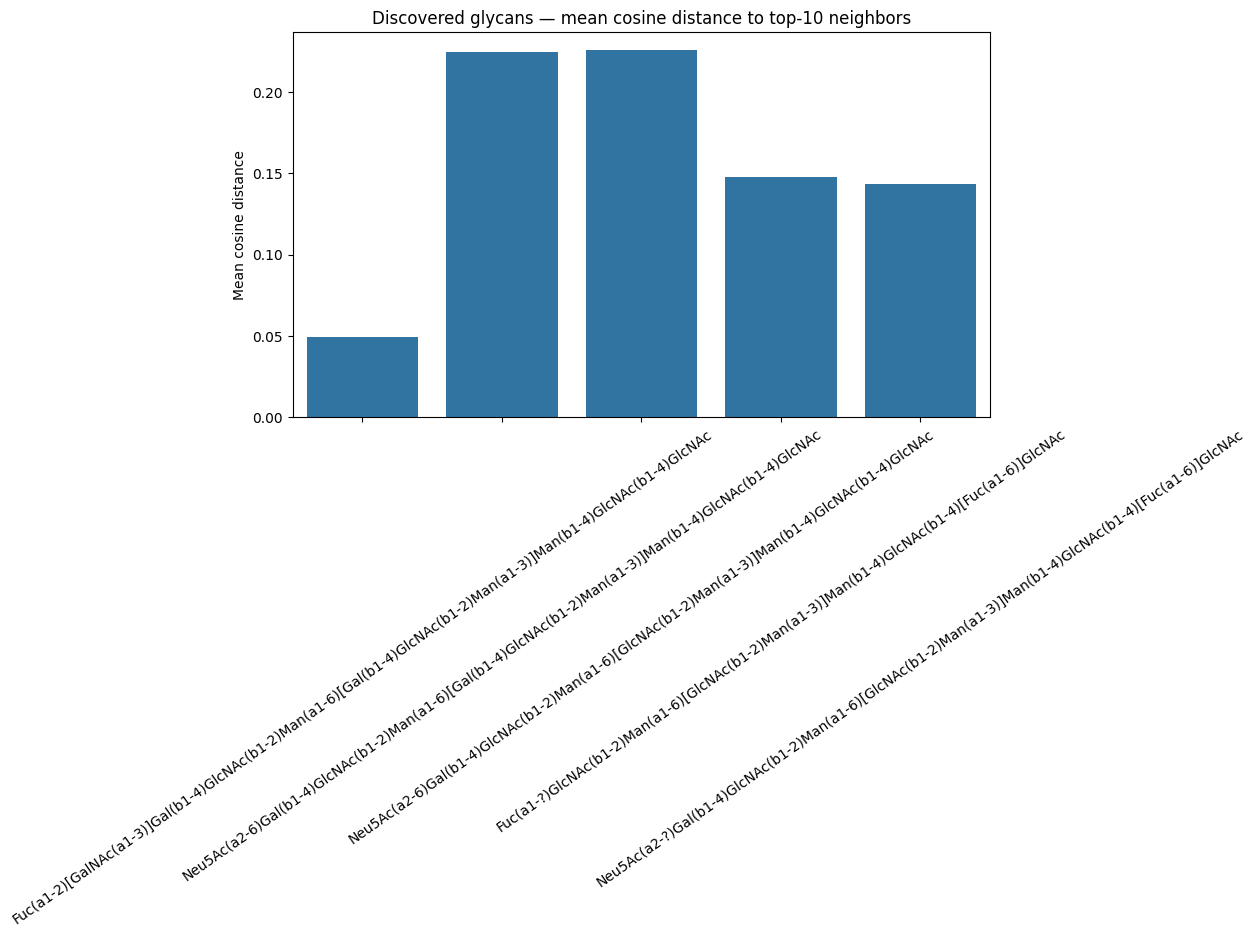

c:\Users\zakar\OneDrive\Bureau\ml-internship\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)


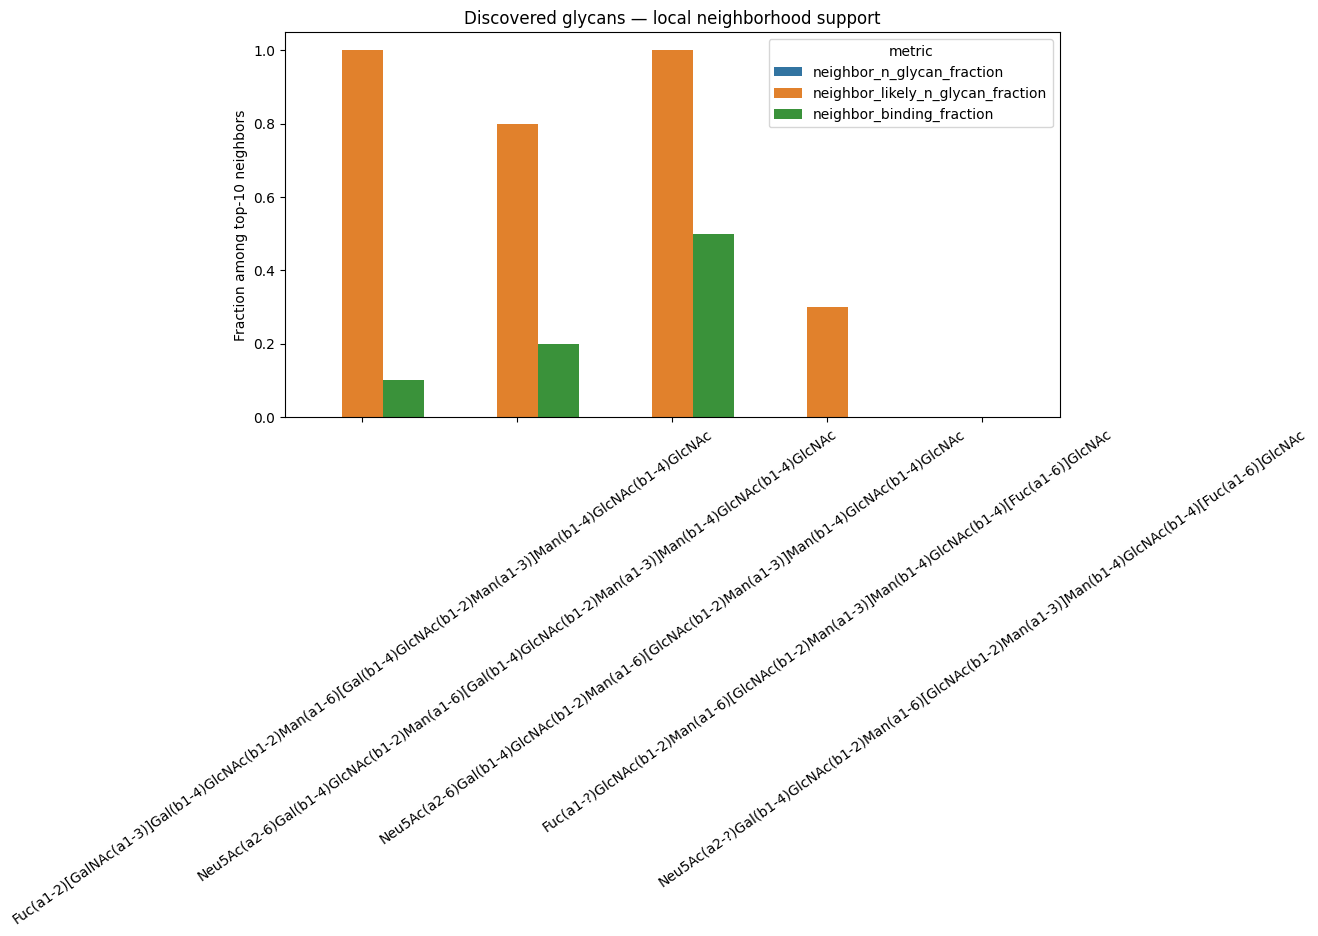

In [32]:
fig = plot_discovered_neighbor_distances(neighborhood_summary)
plt.show()

fig = plot_discovered_neighbor_support(neighborhood_summary)
plt.show()

In [33]:
neighborhood_neighbors.head(50)

,anchor_sequence,neighbor_rank,neighbor_sequence,cosine_distance,neighbor_is_n_glycan,neighbor_likely_n_glycan,neighbor_has_binding_exact,neighbor_tissue_species,neighbor_tissue_sample,neighbor_disease,neighbor_reference_flag,neighbor_discovered_flag
0,Fuc(a1-2)[GalNAc(a1-3)]Gal(b1-4)GlcNAc(b1-2)Ma...,1,Fuc(a1-2)[GalNAc(a1-3)]Gal(b1-4)GlcNAc(b1-2)Ma...,0.000000,0,1,0,Homo_sapiens,plasma,NaN,1,0
1,Fuc(a1-2)[GalNAc(a1-3)]Gal(b1-4)GlcNAc(b1-2)Ma...,2,Fuc(a1-2)[GalNAc(a1-3)]Gal(b1-4)GlcNAc(b1-2/6)...,0.016630,0,1,0,Homo_sapiens,mammalian_vulva,NaN,1,0
2,Fuc(a1-2)[GalNAc(a1-3)]Gal(b1-4)GlcNAc(b1-2)Ma...,3,Fuc(a1-2)[Gal(a1-3)]Gal(b1-4)GlcNAc(b1-2)Man(a...,0.035790,0,1,0,Homo_sapiens,plasma,NaN,1,0
3,Fuc(a1-2)[GalNAc(a1-3)]Gal(b1-4)GlcNAc(b1-2)Ma...,4,Fuc(a1-2)[Gal(a1-3)]Gal(b1-4)GlcNAc(b1-2)Man(a...,0.035790,0,1,0,Homo_sapiens,plasma,NaN,1,0
4,Fuc(a1-2)[GalNAc(a1-3)]Gal(b1-4)GlcNAc(b1-2)Ma...,5,Fuc(a1-2)Gal(b1-4)GlcNAc(b1-2)Man(a1-6)[Gal(b1...,0.042376,0,1,1,Homo_sapiens,plasma,NaN,1,0
5,Fuc(a1-2)[GalNAc(a1-3)]Gal(b1-4)GlcNAc(b1-2)Ma...,6,Fuc(a1-2)Gal(b1-4)GlcNAc(b1-2/6)[Gal(b1-4)GlcN...,0.065855,0,1,0,Homo_sapiens,mammalian_vulva,NaN,1,0
6,Fuc(a1-2)[GalNAc(a1-3)]Gal(b1-4)GlcNAc(b1-2)Ma...,7,{GlcNAc(b1-4/6)}Neu5Ac(a2-3/6)Gal(b1-4)GlcNAc(...,0.070123,0,1,0,Homo_sapiens,PBMC_cell,NaN,1,0
7,Fuc(a1-2)[GalNAc(a1-3)]Gal(b1-4)GlcNAc(b1-2)Ma...,8,Fuc(a1-2)[GalNAcOMe(a1-3)]Gal(b1-3)GlcNAc(b1-2...,0.075794,0,1,0,NaN,NaN,NaN,1,0
8,Fuc(a1-2)[GalNAc(a1-3)]Gal(b1-4)GlcNAc(b1-2)Ma...,9,Fuc(a1-2)[GalNAcOMe(a1-3)]Gal(b1-3)GlcNAc(b1-2...,0.075825,0,1,0,NaN,NaN,NaN,1,0
9,Fuc(a1-2)[GalNAc(a1-3)]Gal(b1-4)GlcNAc(b1-2)Ma...,10,Fuc(a1-2)[GalNAcOMe(a1-3)]GalOS(b1-3)GlcNAc(b1...,0.075872,0,1,0,NaN,NaN,NaN,1,0


## Decision point  — move from neighborhood inspection to interpretation

The Step 9 neighborhood results are coherent enough to justify downstream interpretation, but not all discovered glycans are supported equally strongly. We therefore proceed with family-level and contextual enrichment, while keeping a confidence hierarchy and avoiding exact overclaiming for the weaker or more ambiguous structures.

In [34]:
from src.task2_embedding import (
    add_structural_family_labels,
    summarize_neighbor_context_layers,
    summarize_discovered_motif_proxies,
    build_discovered_neighbor_protein_support,
    compare_discovered_neighbor_robustness,
    build_similarity_network,
    plot_similarity_network,
    build_anchor_protein_bipartite_network,
    plot_anchor_protein_bipartite_network,
    build_embedding_report_table,
    build_final_discovered_enrichment_table,
    build_linear_embedding_layout,
)

In [35]:
final_interpretation_set = add_structural_family_labels(final_interpretation_set)

In [36]:
neighborhood_summary_struct, neighborhood_neighbors_struct = summarize_discovered_glycan_neighborhoods(
    embedding_df=filtered_embedding_suite["candidate_embeddings"]["sequence_token_only"],
    canonical_master=final_interpretation_set,
    binding_block=filtered_embedding_suite["raw_blocks"]["binding"],
    k=10,
)

The Step 9 neighborhoods are sufficiently coherent to justify downstream interpretation, but the support is not uniform across all discovered glycans. We therefore enrich each discovered glycan with three complementary layers: structural family / motif proxies, inferred protein context from binding-supported neighbors, and a provisional disease-context profile derived from the neighborhood metadata.

In [37]:
context_layers = summarize_neighbor_context_layers(
    neighborhood_neighbors=neighborhood_neighbors,
    top_k=10,
)
context_layers

,anchor_sequence,neighbor_human_fraction,neighbor_disease_any_fraction,neighbor_cancer_fraction,context_profile
0,Fuc(a1-2)[GalNAc(a1-3)]Gal(b1-4)GlcNAc(b1-2)Ma...,0.7,0.0,0.0,human structural neighborhood
1,Fuc(a1-?)GlcNAc(b1-2)Man(a1-6)[GlcNAc(b1-2)Man...,0.5,0.0,0.0,human structural neighborhood
2,Neu5Ac(a2-6)Gal(b1-4)GlcNAc(b1-2)Man(a1-6)[Gal...,1.0,0.2,0.2,cancer-associated human neighborhood
3,Neu5Ac(a2-6)Gal(b1-4)GlcNAc(b1-2)Man(a1-6)[Glc...,0.7,0.2,0.2,cancer-associated human neighborhood
4,Neu5Ac(a2-?)Gal(b1-4)GlcNAc(b1-2)Man(a1-6)[Glc...,0.8,0.2,0.1,general disease-associated human neighborhood


In [38]:
motif_proxy_summary = summarize_discovered_motif_proxies(
    neighborhood_neighbors=neighborhood_neighbors,
    top_k=10,
    top_n=10,
)
motif_proxy_summary

,anchor_sequence,top_motif_proxies,top_family_labels
0,Fuc(a1-2)[GalNAc(a1-3)]Gal(b1-4)GlcNAc(b1-2)Ma...,"[(PAIR_Man__GlcNAc, 11), (PAIR_Man__Gal, 11), ...","[(N-glycan-like, 11), (branched, 11), (core-Gl..."
1,Fuc(a1-?)GlcNAc(b1-2)Man(a1-6)[GlcNAc(b1-2)Man...,"[(PAIR_Man__GlcNAc, 11), (LNK_b1-4, 11), (PAIR...","[(fucosylated, 11), (branched, 11), (ambiguous..."
2,Neu5Ac(a2-6)Gal(b1-4)GlcNAc(b1-2)Man(a1-6)[Gal...,"[(RES_GlcNAc, 11), (RES_Gal, 10), (PAIR_Gal__G...","[(branched, 11), (N-glycan-like, 9), (sialylat..."
3,Neu5Ac(a2-6)Gal(b1-4)GlcNAc(b1-2)Man(a1-6)[Glc...,"[(PAIR_Man__GlcNAc, 11), (PAIR_Neu5Ac__Gal, 11...","[(N-glycan-like, 11), (sialylated, 11), (branc..."
4,Neu5Ac(a2-?)Gal(b1-4)GlcNAc(b1-2)Man(a1-6)[Glc...,"[(PAIR_Man__GlcNAc, 11), (PAIR_GlcNAc__Man, 11...","[(fucosylated, 11), (branched, 11), (sialylate..."


In [39]:
protein_summary, protein_long = build_discovered_neighbor_protein_support(
    neighborhood_neighbors=neighborhood_neighbors,
    binding_standardized=audit["binding_standardized"],
    top_k=10,
    top_n_proteins=8,
)

protein_summary

,anchor_sequence,top_proteins
0,Fuc(a1-2)[GalNAc(a1-3)]Gal(b1-4)GlcNAc(b1-2)Ma...,"[(Exotoxin A, 0.2), (LOX-1, 0.2), (Mannose Bin..."
1,Fuc(a1-?)GlcNAc(b1-2)Man(a1-6)[GlcNAc(b1-2)Man...,[]
2,Neu5Ac(a2-6)Gal(b1-4)GlcNAc(b1-2)Man(a1-6)[Gal...,"[(A/Aichi/2/1968(H3N2), 0.625), (A/California/..."
3,Neu5Ac(a2-6)Gal(b1-4)GlcNAc(b1-2)Man(a1-6)[Glc...,"[(A/Anhui/1/2013(H7N9), 2.176190476190476), (A..."
4,Neu5Ac(a2-?)Gal(b1-4)GlcNAc(b1-2)Man(a1-6)[Glc...,[]


In [40]:
robustness_df = compare_discovered_neighbor_robustness(
    final_neighbors=neighborhood_neighbors,
    reference_neighbors=neighborhood_neighbors_struct,
    top_k=10,
)
robustness_df

,anchor_sequence,neighbor_robustness_jaccard
0,Fuc(a1-2)[GalNAc(a1-3)]Gal(b1-4)GlcNAc(b1-2)Ma...,0.428571
1,Fuc(a1-?)GlcNAc(b1-2)Man(a1-6)[GlcNAc(b1-2)Man...,0.428571
2,Neu5Ac(a2-6)Gal(b1-4)GlcNAc(b1-2)Man(a1-6)[Gal...,0.052632
3,Neu5Ac(a2-6)Gal(b1-4)GlcNAc(b1-2)Man(a1-6)[Glc...,0.250000
4,Neu5Ac(a2-?)Gal(b1-4)GlcNAc(b1-2)Man(a1-6)[Glc...,0.333333


The final ranking is based on Task 2 evidence rather than on exact Task 1 biomarker tiers, because the Task 1 to Task 2 handoff is still unresolved at the feature-to-glycan mapping level. The resulting tiers should therefore be interpreted as a provisional contextual prioritization of the discovered glycans.

In [41]:
final_layout = build_linear_embedding_layout(
    embedding_df=filtered_embedding_suite["candidate_embeddings"][final_embedding_name],
    canonical_master=final_interpretation_set,
    embedding_name=final_embedding_name,
)

## Final discovered-glycan ranking

I combine neighborhood coherence, N-glycan consistency, contextual metadata support, protein-context support, and robustness across embeddings into a final Task 2 prioritization score. Because the Task 1 feature-to-glycan handoff remains unresolved, these tiers should be interpreted as Task 2 contextual priorities rather than exact end-to-end biomarker ranks.

In [43]:
final_discovered_enrichment = build_final_discovered_enrichment_table(
    interpretation_set=final_interpretation_set,
    neighborhood_summary=neighborhood_summary,
    context_layers=context_layers,
    motif_proxy_summary=motif_proxy_summary,
    protein_summary=protein_summary,
    robustness_df=robustness_df,
    final_embedding_name=final_embedding_name,
    embedding_coords=final_layout,
    task1_handoff=None,
)

final_discovered_enrichment

,canonical_sequence,composition,family_labels_str,has_binding_exact,likely_n_glycan,anchor_sequence,anchor_is_n_glycan,anchor_likely_n_glycan,anchor_has_binding_exact,mean_cosine_distance_top10,...,top_proteins,neighbor_robustness_jaccard,embedding_x,embedding_y,task1_biomarker_tier,neighborhood_confidence_score,task2_priority_score,priority_tier,final_embedding_name,final_interpretation_note
0,Fuc(a1-2)[GalNAc(a1-3)]Gal(b1-4)GlcNAc(b1-2)Ma...,"{'Hex': 5, 'HexNAc': 5, 'dHex': 1}",N-glycan-like | fucosylated | GalNAc-bearing |...,0,1,Fuc(a1-2)[GalNAc(a1-3)]Gal(b1-4)GlcNAc(b1-2)Ma...,0,1,0,0.049405,...,Exotoxin A (0.20); LOX-1 (0.20); Mannose Bindi...,0.428571,0.556609,0.988497,unresolved_task1_handoff,0.835315,0.508452,Tier B,structure_metadata_binding,strong N-glycan-like neighborhood; limited pro...
1,Neu5Ac(a2-6)Gal(b1-4)GlcNAc(b1-2)Man(a1-6)[Glc...,"{'Hex': 4, 'HexNAc': 4, 'Neu5Ac': 1}",N-glycan-like | sialylated | branched | core-G...,1,1,Neu5Ac(a2-6)Gal(b1-4)GlcNAc(b1-2)Man(a1-6)[Glc...,0,1,1,0.225680,...,A/Anhui/1/2013(H7N9) (2.18); A/Puerto Rico/8/1...,0.250000,0.571506,0.478677,unresolved_task1_handoff,0.247734,0.444789,Tier C,structure_metadata_binding,strong N-glycan-like neighborhood; good protei...
2,Neu5Ac(a2-6)Gal(b1-4)GlcNAc(b1-2)Man(a1-6)[Gal...,"{'Hex': 5, 'HexNAc': 4, 'Neu5Ac': 1}",N-glycan-like | sialylated | branched | core-G...,1,1,Neu5Ac(a2-6)Gal(b1-4)GlcNAc(b1-2)Man(a1-6)[Gal...,0,1,1,0.224546,...,A/Aichi/2/1968(H3N2) (0.62); A/California/4/20...,0.052632,0.844172,0.992755,unresolved_task1_handoff,0.251513,0.311147,Tier C,structure_metadata_binding,strong N-glycan-like neighborhood; limited pro...
3,Fuc(a1-?)GlcNAc(b1-2)Man(a1-6)[GlcNAc(b1-2)Man...,"{'dHex': 2, 'HexNAc': 4, 'Hex': 3}",fucosylated | ambiguous-linkage | branched,0,0,Fuc(a1-?)GlcNAc(b1-2)Man(a1-6)[GlcNAc(b1-2)Man...,0,0,0,0.147532,...,,0.428571,-0.279685,-0.192210,unresolved_task1_handoff,0.508228,0.255325,Tier C,structure_metadata_binding,partial N-glycan-like neighborhood; no direct ...
4,Neu5Ac(a2-?)Gal(b1-4)GlcNAc(b1-2)Man(a1-6)[Glc...,"{'Neu5Ac': 1, 'Hex': 4, 'HexNAc': 4, 'dHex': 1}",sialylated | fucosylated | ambiguous-linkage |...,0,0,Neu5Ac(a2-?)Gal(b1-4)GlcNAc(b1-2)Man(a1-6)[Glc...,0,0,0,0.143625,...,,0.333333,0.014498,-0.201066,unresolved_task1_handoff,0.521249,0.204708,Tier C,structure_metadata_binding,weak N-glycan-control support; no direct prote...


## Embedding model selection summary

The final biological interpretation should be tied to an explicitly validated representation. I therefore summarize each candidate embedding with its main quantitative strengths and weaknesses, together with a final keep/drop decision.

The final enrichment table is the main Task 2 deliverable. It summarizes, for each discovered glycan, the structural family assignment, neighborhood support, inferred biological context, protein-context evidence, and final interpretation tier.

In [44]:
embedding_report = build_embedding_report_table(embedding_eval)
embedding_report

,embedding_name,n_dimensions,n_glycan_silhouette,n_glycan_knn_purity_at5,species_neighbor_purity_at5,species_labeled_anchors,sample_neighbor_purity_at5,sample_labeled_anchors,disease_neighbor_purity_at5,disease_labeled_anchors,binding_jaccard_at5,binding_labeled_anchors,pros,cons,final_decision
0,sequence_token_only,32,0.359461,0.998545,0.309859,1917.0,0.215996,1938.0,0.070632,269.0,0.137768,276.0,Best structural coherence; strongest N-glycan ...,Weaker metadata and binding context.,keep_as_structural_reference
1,structure,44,0.317700,0.996050,0.407825,1917.0,0.302786,1938.0,0.133829,269.0,0.121278,276.0,Balanced structural baseline.,Adds limited value once metadata/binding fusio...,drop_after_ablation
2,composition_only,12,0.132056,0.982536,0.354304,1917.0,0.253148,1938.0,0.110037,269.0,0.175106,276.0,Simple interpretable baseline.,Lower overall contextual performance.,drop_after_ablation
3,structure_metadata_binding,76,0.132260,0.980042,0.777778,1917.0,0.676367,1938.0,0.228253,269.0,0.281007,276.0,Best overall contextual embedding; strongest s...,Slight loss in pure structural sharpness relat...,keep_as_final_interpretation_embedding
4,structure_metadata,60,0.132553,0.977339,0.781534,1917.0,0.678122,1938.0,0.230483,269.0,0.120069,276.0,Very strong metadata neighborhoods.,Binding context absent; slightly weaker than s...,secondary_backup


The embedding evaluation report documents why the final interpretation embedding was selected. This keeps the Task 2 workflow disciplined: the final biological claims are tied back to explicit representation-level validation rather than to an arbitrary model choice.

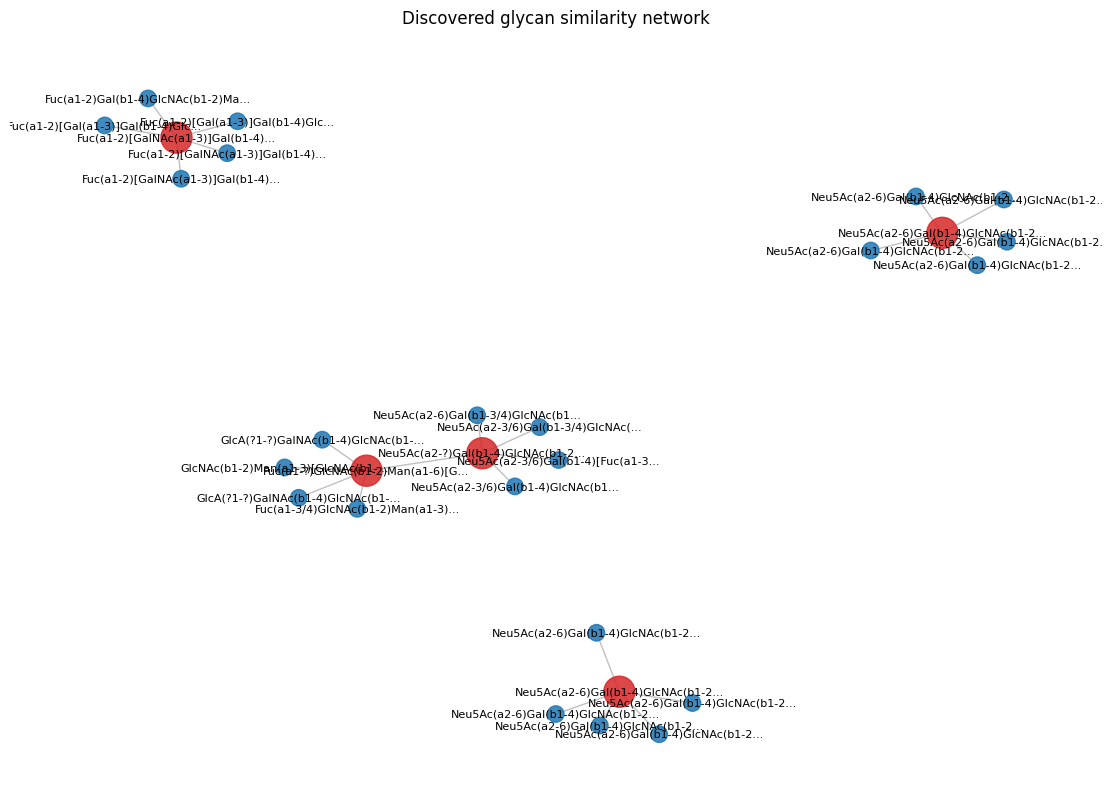

In [45]:
similarity_graph = build_similarity_network(
    neighborhood_neighbors=neighborhood_neighbors,
    top_k=5,
)

fig = plot_similarity_network(similarity_graph)
plt.show()

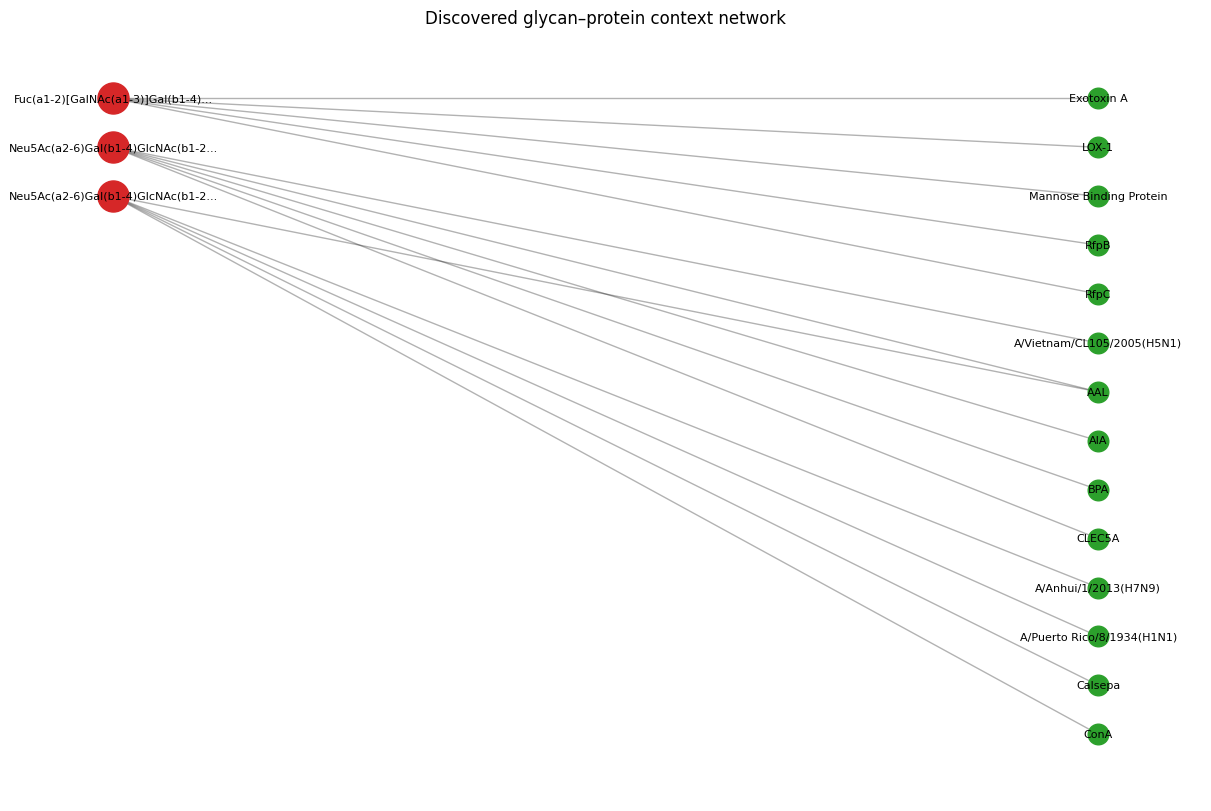

In [46]:
protein_graph = build_anchor_protein_bipartite_network(
    protein_long=protein_long,
    top_n_edges_per_anchor=5,
)

fig = plot_anchor_protein_bipartite_network(protein_graph)
plt.show()

## Task 2 conclusion

Task 2 produced a validated glycan embedding workflow and a final enriched interpretation table for the discovered glycans. The analysis showed that simple interpretable representations already captured strong structural organization, especially for N-glycan controls, while multimodal fusion with metadata and binding information improved contextual neighborhood quality.

Based on the validation results, the final interpretation space was chosen as the `structure_metadata_binding` embedding because it gave the best overall balance between structural organization and biological context. The discovered glycans projected into coherent neighborhoods with varying levels of support: some showed strong N-glycan-like and protein-context evidence, while others remained more weakly contextualized due to ambiguous linkage information or limited external support.

Overall, the final Task 2 output should be interpreted as a contextual prioritization framework rather than as direct biological proof. Its main value is to organize the discovered glycans into structural families, neighborhood-supported hypotheses, and ranked interpretation tiers that can guide downstream experimental validation.